# **Congressional Vote Prediction**: Predicting U.S. Congress Votes with Matrix Factorization

<br>

In this tutorial, we'll build a recommendation engine to predict congressional votes using [Apache Spark](https://spark.apache.org/) and voting data from [Voteview](https://voteview.com/). We'll walk you through raw CSV files to a predictive model in a streamlined, scalable workflow with the following steps:
  * Explore and process real-world legislative voting records with Spark.
  * Transform raw vote data into a `user-item-rating` format suitable for modeling.
  * Apply collaborative filtering using the **Alternating Least Squares (ALS)** algorithm.
  * Train a model to uncover latent political factors from voting patterns.
  * Evaluate model performance and generate predictions for specific legislators.

**Credits**

Peter Zhang

**Compatibility**

| Platform | Compatible | Recommended | Notes |
| :--- | :--- | :--- | :--- |
| **Local Machine** | ✅ Yes | ✅ Yes | A standard laptop (e.g., MacBook, Windows w/ WSL2) with at least 8GB of RAM is sufficient. |
| **Google Colab** | ✅ Yes | ✅ Yes | Works well within Colab's free tier. A simple and effective way to run the tutorial. |
| **Midway** | ✅ Yes | ✅ Yes | The code is fully compatible with cloud-based Spark environments and can be scaled to larger datasets. |

## The Big Idea: Netflix for Congress

Before a single line of code is written, let's nail down the core concept. We're going to creatively reframe the congressional voting as a movie recommendation task. The analogy is surprisingly direct:

| Movie Recommendation   | Congress Voting Prediction                     |
| :--------------------- | :-------------------------------------- |
| **User**               | A Congress Member                  |
| **Item**               | A roll-call vote (a specific bill)      |
| **Rating** (1-5 stars) | Vote (**Yea** = 👍, **Nay** = 👎) |

Just as Netflix learns your "taste" in movies by looking at what you've rated, our model will learn a congressperson's "political ideology" by looking at how they've voted.

## The Tool: Alternating Least Squares (ALS)

We will apply **Alternating Least Squares (ALS)**, a staple of collaborative filtering. At its heart, ALS works by discovering **latent factors**—hidden, underlying characteristics that explain the relationships in the data.

- For a **congressperson (user)**, these latent factors might represent their position on a spectrum from "pro-environment" to "pro-business," or from "fiscally conservative" to "fiscally liberal." These are not explicit labels; they are abstract dimensions the model learns on its own.
- For a **bill (item)**, the latent factors represent its own ideological makeup. A bill might have a strong "pro-environment" component and a weak "fiscal" component.

ALS takes a large, sparse matrix of who-voted-what and approximates it as the product of two smaller, dense matrices alternatively: a "user-factor" matrix and an "item-factor" matrix. It's called **_alternating_** because it cleverly solves for one matrix while holding the other constant, and then swaps, repeating the process until its guesses converge.

This process allows the model to predict a "rating" (a vote) for a user-item pair it has never seen before.

For more technical details, you can check out the official [Spark MLlib documentation for ALS](https://spark.apache.org/docs/latest/ml-collaborative-filtering.html).

## The Data: Sourced from Voteview

Every data project needs high-quality raw materials. We'll use data from [**Voteview**](https://voteview.com/data), a phenomenal academic project run by UCLA that provides comprehensive data on congressional roll-call votes throughout U.S. history.

For this tutorial, we'll use a pre-prepared dataset containing all **votes from the 117th U.S. House of Representatives (2021-2023)**. The key columns for our project are:

- `icpsr`: A unique numerical ID for each member of Congress. This will be our `user`.
- `rollnumber`: A unique numerical ID for each bill or resolution that was voted on. This will be our `item`.
- `cast_code`: A number from 1 to 9 representing how the member voted. This will become our `rating`.

Now, let's build our workshop and start shaping this data.


## Step 1: Setting Up PySpark

First, we need to import our tools (libraries) and start up our data-processing engine (Spark).


In [3]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

from pyspark.sql import SparkSession
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.sql import functions as F
from pyspark.sql.functions import col, when
from pyspark.mllib.evaluation import MulticlassMetrics

In [4]:
SEED = 42
DATA_DIR = "./voteview"

In [5]:
# Spark is a powerful tool for working with large datasets.
# The SparkSession is our main entry point to using it.
print("Starting Spark Session...")
spark = SparkSession.builder.appName("CongressVotePrediction").getOrCreate()
print("Spark Session created.")

Starting Spark Session...
Spark Session created.


## Step 2: Loading and Exploring the Raw Data

Let's load our Voteview CSV file into a Spark DataFrame and take a first look.


In [6]:
# Run this block to download the data if you are running this as a standalone notebook on Colab
!mkdir voteview
!wget https://voteview.com/static/data/out/votes/HS117_votes.csv
!mv HS117_votes.csv voteview

--2025-10-21 05:39:43--  https://voteview.com/static/data/out/votes/HS117_votes.csv
Resolving voteview.com (voteview.com)... 128.97.229.84
Connecting to voteview.com (voteview.com)|128.97.229.84|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15196217 (14M) [application/octet-stream]
Saving to: ‘HS117_votes.csv’

HS117_votes.csv     100%[===================>]  14.49M  15.5MB/s    in 0.9s    

2025-10-21 05:39:45 (15.5 MB/s) - ‘HS117_votes.csv’ saved [15196217/15196217]



In [7]:
# Load the data from the CSV file.
# The 'header=True' option tells Spark to use the first row as column names.
raw_votes_df = spark.read.csv(os.path.join(DATA_DIR, "HS117_votes.csv"), header=True)

print("--- Raw Data Schema ---")
# printSchema() is a great way to see the column headers and their data types.
raw_votes_df.printSchema()

print("--- Raw Data Sample (first 5 rows) ---")
# .show() lets us peek at the actual data.
# 'truncate=False' ensures we see the full content of each column.
raw_votes_df.show(5, truncate=False)

--- Raw Data Schema ---
root
 |-- congress: string (nullable = true)
 |-- chamber: string (nullable = true)
 |-- rollnumber: string (nullable = true)
 |-- icpsr: string (nullable = true)
 |-- cast_code: string (nullable = true)
 |-- prob: string (nullable = true)

--- Raw Data Sample (first 5 rows) ---
+--------+-------+----------+-------+---------+-----+
|congress|chamber|rollnumber|icpsr  |cast_code|prob |
+--------+-------+----------+-------+---------+-----+
|117     |House  |1         |14066.0|6        |100.0|
|117     |House  |1         |14854.0|6        |100.0|
|117     |House  |1         |14863.0|6        |99.8 |
|117     |House  |1         |14873.0|1        |100.0|
|117     |House  |1         |15019.0|1        |92.8 |
+--------+-------+----------+-------+---------+-----+
only showing top 5 rows



When running this code, you'll see columns like `icpsr`, `rollnumber`, and `cast_code`. Notice that most columns are currently strings, which we'll need to fix.

## Step 3: Data Preprocessing

The most critical step in any data science project. Our raw data is like uncut lumber; we need to shape it into the exact `(user, item, rating)` format that the ALS algorithm requires by:

1.  **Select Necessary Columns:** We only need `icpsr`, `rollnumber`, and `cast_code`.
2.  **Create the `rating` Column:** We'll convert the `cast_code` into a simple numeric rating that captures the member's preference.
    - **Yea** (codes 1, 2, 3) will become **1.0** (they "liked" or supported the bill).
    - **Nay** (codes 4, 5, 6) will become **-1.0** (they "disliked" or opposed the bill).
3.  **Filter Out Non-Votes:** We'll ignore votes like "Present" or "Not Voting" (codes 7, 8, 9, 0) because they don't provide a clear preference signal for our model.
4.  **Format for ALS:** Rename the columns to `user`, `item`, and `rating`, and cast `user` and `item` to integers, as required by Spark's ALS implementation.

<!-- end list -->


In [8]:
# The 'cast_code' is a number from 1-9. We need to convert this into rating.
# We use a `when` statement, which is like an IF/THEN/ELSE for DataFrames.
# Yea votes (codes 1, 2, 3) become 1.0
# Nay votes (codes 4, 5, 6) become -1.0
votes_df = raw_votes_df.withColumn(
    "rating",
    when(col("cast_code").isin([1, 2, 3]), 1.0)
    .when(col("cast_code").isin([4, 5, 6]), -1.0)
    .otherwise(0.0),  # We'll filter these out in the next step
)

# Now, filter out the rows where the rating is 0.0 (the non-votes).
votes_df = votes_df.filter(col("rating") != 0.0)

# Finally, select and rename the columns to the standard names that ALS expects.
final_df = votes_df.select(
    col("icpsr").alias("user"), col("rollnumber").alias("item"), col("rating")
)

# ALS requires the 'user' and 'item' columns to be integers.
# Let's cast them to the correct type.
final_df = final_df.withColumn("user", col("user").cast("integer"))
final_df = final_df.withColumn("item", col("item").cast("integer"))

# It's always good practice to drop any rows that might have null values
# after transformations.
final_df = final_df.na.drop()

print("\n--- Preprocessed Data Sample (first 10 rows) ---")
# Let's look at our beautifully prepared data!
final_df.show(10)
print("Preprocessing complete!")


--- Preprocessed Data Sample (first 10 rows) ---
+-----+----+------+
| user|item|rating|
+-----+----+------+
|14066|   1|  -1.0|
|14854|   1|  -1.0|
|14863|   1|  -1.0|
|14873|   1|   1.0|
|15019|   1|   1.0|
|15029|   1|   1.0|
|15410|   1|   1.0|
|15433|   1|   1.0|
|15438|   1|   1.0|
|15446|   1|  -1.0|
+-----+----+------+
only showing top 10 rows

Preprocessing complete!


## Step 4: Matrix Factorization with ALS

Now for the magic. We'll feed our processed data to the ALS algorithm. In comparison to the Dask ALS we implemented in [Tutorial 4.1.1](./1.dask_movielens_100k.ipynb), Spark employs a more advanced block-based approach, grouping users and items to solve larger matrix equations more efficiently.

An essential practice is to split the data: we'll use **80% to teach the model** (`training` data) and hold back **20% to test how well it performs** (`test` data).


In [9]:
# Split data with 80% for training and 20% for testing.
# The 'seed' ensures that the split is reproducible every time we run the code.
(training, test) = final_df.randomSplit([0.8, 0.2], seed=SEED)
print(
    f"\nData split into {training.count()} training rows and {test.count()} test rows."
)


Data split into 409674 training rows and 102387 test rows.


In [10]:
# Now we configure our ALS model. Let's break down the key settings:
# - rank=10: The model will find 10 hidden "latent factors" for each user and item.
# - maxIter=5: The model will refine its guesses 5 times over the data.
# - regParam=0.01: A small penalty to prevent the model from "memorizing" the data (overfitting).
# - coldStartStrategy="nan": If the test data has a user/item not seen in training, use `nan` as the predicted value.
# - nonnegative=False: Our ratings can be negative (-1.0), so we MUST set this to False.
als = ALS(
    rank=10,
    maxIter=5,
    regParam=0.01,
    userCol="user",
    itemCol="item",
    ratingCol="rating",
    coldStartStrategy="nan",
    nonnegative=False,
    seed=SEED
)

# This is where the learning happens! We fit the model to our training data.
print("\nTraining the ALS model... (This may take a moment)")
model = als.fit(training)
print("Model training complete.")


Training the ALS model... (This may take a moment)
Model training complete.


## Step 5: Evaluation

How can we tell whether our model performs well? We will use the `test` dataset to evaluate model performance by comparing the predicted votes to actual votes, and calculate the **Root Mean Squared Error (RMSE)**:

$$RMSE = \sqrt{\frac{\sum_{i=1}^{n}(\text{actual}_i - \text{prediction}_i)^2}{n}}$$

It measures the difference between the predicted rating and the actual rating,  **lower is better**.


In [11]:
print("Making predictions on the test set...")
predictions = model.transform(test)
print(f"The test set has {test.count()} items, while the model generated {predictions.count()} predictions.")

Making predictions on the test set...
The test set has 102387 items, while the model generated 102387 predictions.


In [12]:
print("--- Sample Predictions ---")
# The 'prediction' column is the model's predicted "rating".
predictions.sample(0.01, seed=SEED).show(10)

--- Sample Predictions ---
+-----+----+------+-----------+
| user|item|rating| prediction|
+-----+----+------+-----------+
|21116| 692|  -1.0|-0.83301914|
|21715| 196|   1.0| 0.94301236|
|21715| 621|   1.0| 0.91336614|
|21545| 678|  -1.0|-0.94761556|
|22107| 615|  -1.0| -0.8830581|
|22107| 683|  -1.0|-0.91649926|
|22107| 716|   1.0| 0.77395165|
|21373| 678|   1.0|    0.93198|
|21978| 188|   1.0| 0.93620265|
|21978| 359|   1.0|   0.873594|
+-----+----+------+-----------+
only showing top 10 rows



In [13]:
# Create an evaluator to measure the model's performance.
evaluator = RegressionEvaluator(
    metricName="rmse", labelCol="rating", predictionCol="prediction"
)
rmse = evaluator.evaluate(predictions)
print(f"\nRoot-mean-square error (RMSE) on test data = {rmse}")


Root-mean-square error (RMSE) on test data = 0.3268420038776537


**An important insight on RMSE:** for this task, the **sign** of the prediction is more important than its exact value:
- A prediction of `1.5` for an actual "Yea" vote (`1.0`) is a _correct_ prediction in terms of outcome.
- A prediction of `-1.2` for that same "Yea" vote is an _incorrect_ prediction.

RMSE doesn't capture this binary success well (it would penalize the `1.5` prediction). So we will convert predicted values to 1 and -1 and directly evaluate the binary classification results.

In [14]:
# Binarize labels and predictions (-1 / 1), and drop any null predictions
bin_df = (
    predictions
    .where(F.col("prediction").isNotNull())
    .withColumn("label_bin", F.when(F.col("rating") >= 0, F.lit(1.0)).otherwise(F.lit(-1.0)))
    .withColumn("pred_bin",  F.when(F.col("prediction") >= 0, F.lit(1.0)).otherwise(F.lit(-1.0)))
    .select("label_bin", "pred_bin")
)

print(f"\nBinary evaluation on {bin_df.count()} rows (after dropping null predictions).")


Binary evaluation on 102387 rows (after dropping null predictions).


In [15]:
labels = [-1.0, 1.0]  # keep ordering consistent

# Classification metrics via MulticlassMetrics
preds_and_labels = bin_df.select("pred_bin", "label_bin").rdd.map(lambda r: (float(r.pred_bin), float(r.label_bin)))
metrics = MulticlassMetrics(preds_and_labels)

# Extract the confusion matrix as a local 2x2 array
cm_local = metrics.confusionMatrix().toArray()

# Per-class report
def fmt(x):
    return f"{x:.4f}"

print("\n--- Classification Report ---")
for lbl in labels:
    precision = metrics.precision(lbl)
    recall    = metrics.recall(lbl)
    f1        = metrics.fMeasure(lbl)
    support   = bin_df.filter(F.col("label_bin") == lbl).count()
    name = "Class +1" if lbl == 1.0 else "Class -1"
    print(f"{name:9s}  precision={fmt(precision)}  recall={fmt(recall)}  f1-score={fmt(f1)}  support={support}")

# Overall metrics
accuracy  = metrics.accuracy
w_prec    = metrics.weightedPrecision
w_rec     = metrics.weightedRecall
w_f1      = metrics.weightedFMeasure()
print(f"\nAccuracy={fmt(accuracy)}  Weighted Precision={fmt(w_prec)}  Weighted Recall={fmt(w_rec)}  Weighted F1={fmt(w_f1)}")

/usr/local/lib/python3.12/dist-packages/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



--- Classification Report ---
Class -1   precision=0.9518  recall=0.9416  f1-score=0.9467  support=33301
Class +1   precision=0.9720  recall=0.9770  f1-score=0.9745  support=69086

Accuracy=0.9655  Weighted Precision=0.9654  Weighted Recall=0.9655  Weighted F1=0.9655


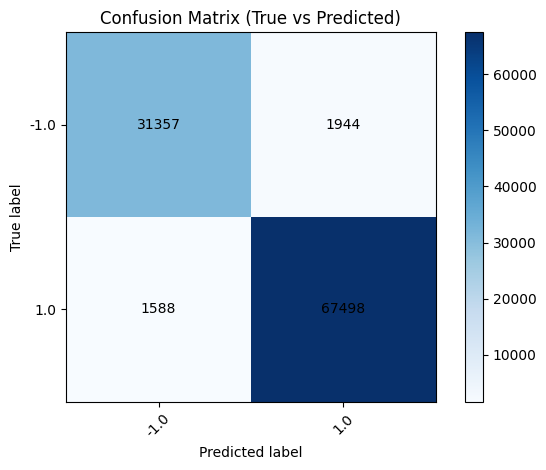

In [16]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
plt.imshow(cm_local, interpolation='nearest', cmap="Blues")
plt.title("Confusion Matrix (True vs Predicted)")
plt.colorbar()
tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)
plt.xlabel("Predicted label")
plt.ylabel("True label")

# Annotate counts
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, int(cm_local[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()


## Step 6: Putting It to Use

This is the payoff\! We can now use our trained model to predict votings. Let's ask it to find the **top 10 bills a specific congressperson is most likely to support**.


In [17]:
# Let's grab a user from our test set as an example.
if test.count() > 0:
    user_id = test.select("user").first()[0]
    print(f"\n--- Generating top 10 vote predictions for user: {user_id} ---")

    # This function generates recommendations for a specific user (or subset of users).
    # We ask for 10 recommendations for the user we selected.
    user_recs = model.recommendForUserSubset(
        test.filter(col("user") == user_id).limit(1), 10
    )

    print("Recommendations (Bill ID, Predicted Score):")
    # The result is a column named 'recommendations' containing a list of (item, rating) structs.
    user_recs.select("recommendations").show(truncate=False)
else:
    print("\nTest set is empty, cannot generate sample recommendations.")


--- Generating top 10 vote predictions for user: 14066 ---
Recommendations (Bill ID, Predicted Score):
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|recommendations                                                                                                                                                                  |
+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|[{119, 1.3268329}, {555, 1.31218}, {839, 1.1860601}, {690, 1.1837077}, {296, 1.1814353}, {935, 1.1487631}, {632, 1.1043062}, {556, 1.0820171}, {530, 1.077241}, {752, 1.0680137}]|
+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Bonus Experiment: The "Cold Start" Problem

Our previous model was trained on 80% of our data. But what happens if we have significantly less data? How does this affect performance, especially for users or bills the model has barely seen? This is known as the **cold start problem**, a common challenge in recommendation systems.

When the ALS model is asked to predict a vote for a user-bill pair where either the user or the bill was not in the training data, it doesn't have enough information to make a guess. Our current `coldStartStrategy="nan"` tells it to output `NaN` (Not a Number).

Instead of just dropping these `NaN` predictions, we'll run an experiment:

1.  **Drastically reduce our training data** to just 5% of the original set.
2.  **Treat the `NaN` predictions as a third class**, which we'll label `0`. This represents an "undecided" or "unknown" prediction.
3.  **Evaluate a 3-class model** (Yea: `1`, Nay: `-1`, Unknown: `0`) to see how often the cold start problem occurs and how it impacts our accuracy.

This approach gives us a clearer picture of how the model behaves when faced with unseen data.

### Retrain the Model on a Tiny Dataset

First, we'll create a new, much smaller training set and retrain our ALS model on it. The test set remains the same so we can make a fair comparison.

In [18]:
# Create a tiny 5% training set to simulate data scarcity
(tiny_training, tiny_testing) = training.randomSplit([0.05, 0.95], seed=SEED)
print(f"Using a tiny training set with only {tiny_training.count()} rows.")

# Configure the same ALS model as before
als_exp = ALS(
    rank=10,
    maxIter=5,
    regParam=0.01,
    userCol="user",
    itemCol="item",
    ratingCol="rating",
    coldStartStrategy="nan", # Intentionally produce NaN for cold starts
    nonnegative=False,
    seed=SEED
)

# Train the model on the tiny dataset
print("\nTraining the ALS model on the tiny dataset...")
model_exp = als_exp.fit(tiny_training)
print("Model training complete.")

Using a tiny training set with only 20542 rows.

Training the ALS model on the tiny dataset...
Model training complete.


### Evaluate with a 3-Class Approach

Now, we'll make predictions on the original test set. The key change is how we handle the results. Instead of filtering out `NaN` values, we use the `coalesce` function to replace them with `0`. We then categorize all predictions and labels into one of three classes: `1.0` (Yea), `-1.0` (Nay), or `0.0` (Unknown).

In [19]:
# Make predictions and handle nulls
predictions_exp = model_exp.transform(tiny_testing)
print(f"The test set has {tiny_testing.count()} items, while the model generated {predictions_exp.count()} predictions.")

# Prepare the dataframe for evaluation
# True Labels (label_bin): -1 or 1
# Predicted Labels (pred_bin): -1, 0 (for NaN), or 1
eval_df = (
    predictions_exp
    .withColumn("label_bin", F.when(F.col("rating") > 0, 1.0).otherwise(-1.0))
    .withColumn(
        "pred_bin",
        F.when(F.isnan("prediction"), 0.0)
          .when(F.col("prediction") > 0, 1.0)
         .when(F.col("prediction") < 0, -1.0)
         .otherwise(0.0) # Cold starts (NaN) become 0.0
    )
)

# Collect data from Spark to a local Pandas DataFrame
# This is safe because the test set is small enough to fit in memory.
print("Collecting results for sklearn evaluation...")
pd_df = eval_df.toPandas()
y_true = pd_df["label_bin"]
y_pred = pd_df["pred_bin"]

#  Generate the classification report and confusion matrix
# Define the full set of labels to ensure all classes are in the report
class_labels = [-1.0, 0.0, 1.0]
class_names = ["Class -1 (Nay)", "Class 0 (Unknown)", "Class +1 (Yea)"]

print("\n--- Classification Report (sklearn) ---")
# Use `zero_division=0` to prevent warnings for classes with no true samples (our Class 0)
report = classification_report(
    y_true, y_pred, labels=class_labels, target_names=class_names, zero_division=0
)
print(report)

The test set has 389132 items, while the model generated 389132 predictions.

--- Classification Report (sklearn) ---
                   precision    recall  f1-score   support

   Class -1 (Nay)       0.74      0.80      0.77    126231
Class 0 (Unknown)       0.00      0.00      0.00         0
   Class +1 (Yea)       0.90      0.87      0.88    262901

         accuracy                           0.84    389132
        macro avg       0.55      0.55      0.55    389132
     weighted avg       0.85      0.84      0.85    389132



### Visualize the 3-Class Confusion Matrix

Finally, we plot our manually-created confusion matrix. The middle column is the most important: it visually represents the cold start problem.

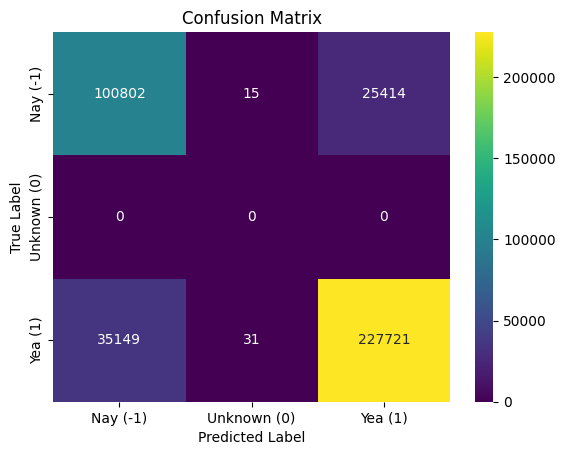

In [20]:
cm_sklearn = confusion_matrix(y_true, y_pred, labels=class_labels)

fig, ax = plt.subplots()
sns.heatmap(cm_sklearn, annot=True, fmt='d', cmap="viridis", ax=ax,
            xticklabels=["Nay (-1)", "Unknown (0)", "Yea (1)"],
            yticklabels=["Nay (-1)", "Unknown (0)", "Yea (1)"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Result Analysis  📈

With a tiny 5% training set, you will likely observe some cold start issues in the test entries (22 + 36 in our case), as well as mediocre accuracy. This experiment proves that collaborative filtering is data-hungry. Without sufficient data to cover most users and items, the model's practical utility is severely limited.

Congratulations\! You've successfully built and evaluated a model to predict congressional votes. But this is just the beginning.

## Where to Go from Here?

- **Tune the Model:** The values we chose for `rank`, `maxIter`, and `regParam` were educated guesses. To find the optimal combination, you can use Spark's `CrossValidator`, which systematically tests different hyperparameter values to find the best-performing model.
- **Analyze the Latent Factors:** The real gold is hidden in `model.userFactors` and `model.itemFactors`. These DataFrames contain the learned ideological DNA of each politician and bill. You could use techniques like PCA or clustering on these factors to discover hidden political blocs or map the main ideological spectrums in Congress.
- **Expand the Scope:** Try running the model on data from the Senate or from different historical eras. Does the model's structure change? What were the key ideological dimensions during the 1960s vs. today?
- **Mitigating the Cold Start Problem:** Try integrating party affliation into the model to mitigate the cold start problem.